In [ ]:
!pip install pandas
!pip install matplotlib

In [2]:
import pandas as pd

train_df = pd.read_csv('data/train_clean.csv')

print(train_df.shape)
train_df.head()

(161297, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"It has no side effect, I take it in combinatio...",9,20-May-12,27
1,95260,Guanfacine,ADHD,My son is halfway through his fourth week of I...,8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"I used to take another oral contraceptive, whi...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,This is my first time using any form of birth ...,8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,Suboxone has completely turned my life around....,9,27-Nov-16,37


## EDA Plan

This notebook explores the cleaned **training set** (`train_clean.csv`) —  The goal isn't general data exploration, but specifically gathering the evidence needed to make informed choices for the upcoming 10-class and 3-class models: checking the **rating distribution** (to decide whether class weighting or stratified sampling is needed), measuring **review length in words** (to set a sensible max sequence length for tokenization), and estimating **vocabulary size** (to size the embedding layer appropriately). Class-distribution checks specific to each task (10-class vs. 3-class) will be revisited briefly inside their respective model notebooks, right before the relevant modeling decisions are made.

rating
1     21619
2      6931
3      6513
4      5012
5      8013
6      6343
7      9456
8     18890
9     27531
10    50989
Name: count, dtype: int64


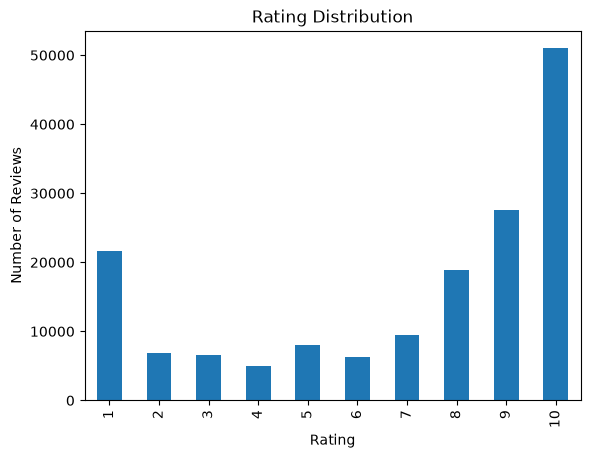

In [10]:
import matplotlib.pyplot as plt

print(train_df['rating'].value_counts().sort_index())


train_df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

And now the distribution in 3-class:

- **Class 1 (rating ≤ 4):** 21,619 + 6,931 + 6,513 + 5,012 = **40,075** (~24.8%)
- **Class 2 (4 < rating < 7):** 8,013 + 6,343 = **14,356** (~8.9%)
- **Class 3 (rating ≥ 7):** 9,456 + 18,890 + 27,531 + 50,989 = **106,866** (~66.3%)


The rating distribution is strongly **U-shaped**, not balanced or normally distributed: people tend to leave a review when they either love or hate a drug, so the extreme ratings (1, and especially 9-10) dominate while the middle ratings (2-6) are comparatively rare. This pattern persists in the 3-class version too — the "medium" bucket (class 2) makes up under 9% of the data, far smaller than the other two classes.

This imbalance has direct consequences for how we evaluate and train both models. Plain accuracy would be a misleading metric here, since a model could score deceptively well just by defaulting to the majority classes (10, or "high") without ever learning to distinguish the minority ones. To address this, we'll report **macro-F1** and a **confusion matrix** alongside accuracy, use **class weighting** in the loss function so misclassifying a rare class is penalized more heavily, and ensure any train/validation split is **stratified** to preserve this same class balance.

In [14]:
train_df['review_word_count'] = train_df['review'].str.split().str.len()
print(train_df['review_word_count'].describe())

print(train_df['review_word_count'].quantile([0.9, 0.95, 0.99]))

count    161297.000000
mean         84.647941
std          45.058434
min           1.000000
25%          48.000000
50%          84.000000
75%         126.000000
max        1894.000000
Name: review_word_count, dtype: float64
0.90    141.0
0.95    146.0
0.99    154.0
Name: review_word_count, dtype: float64


In [15]:
train_df.loc[train_df['review_word_count'].idxmax(), ['drugName', 'condition', 'review']]

drugName                                           Venlafaxine
condition                                             Migraine
review       Two and a half months ago I was prescribed Ven...
Name: 75663, dtype: str

In [16]:
train_df.nlargest(10, 'review_word_count')['review_word_count']

75663     1894
139700    1162
141360    1107
43247     1103
69307     1103
93238      881
153004     881
22050      834
111897     834
150077     765
Name: review_word_count, dtype: int64

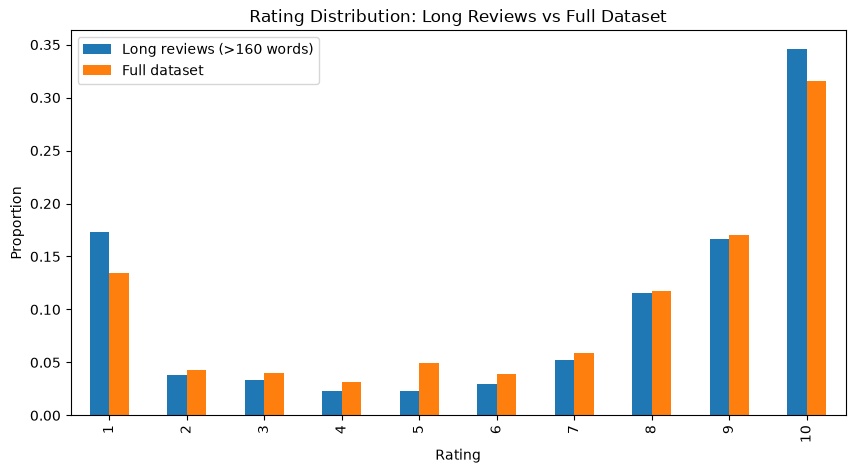

Number of reviews over 160 words: 572 (0.4%)


In [22]:
long_reviews = train_df[train_df['review_word_count'] > 160]

comparison = pd.DataFrame({
    'Long reviews (>160 words)': long_reviews['rating'].value_counts(normalize=True).sort_index(),
    'Full dataset': train_df['rating'].value_counts(normalize=True).sort_index()
})

comparison.plot(kind='bar', figsize=(10, 5))
plt.title('Rating Distribution: Long Reviews vs Full Dataset')
plt.xlabel('Rating')
plt.ylabel('Proportion')
plt.legend()
plt.show()

print(f"Number of reviews over 160 words: {len(long_reviews)} ({len(long_reviews)/len(train_df)*100:.1f}%)") 


Long reviews (>160 words, 0.4% of the dataset) skew toward extreme ratings (more 1s and 10s than the overall distribution), suggesting people write more when they feel strongly about a drug. Since this is a small fraction of the data and the signal is meaningful rather than noise, we keep these reviews rather than dropping them.


We set `max_sequence_length=160` at tokenization time only, leaving the stored `review` column intact — both because the Excel deliverable needs the full review text, and because the GenAI summarization step should work from the complete review.

In [32]:
import re
from collections import Counter

# --- Original (naive) count, for comparison ---
word_counts_raw = Counter()
train_df['review'].str.lower().str.split().apply(word_counts_raw.update)

# --- Cleaned tokenization: strips punctuation, keeps contractions intact ---
def tokenize(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

word_counts_clean = Counter()
train_df['review'].apply(lambda t: word_counts_clean.update(tokenize(t)))

# --- Before/after comparison ---
print(f"Unique words (raw, with punctuation):   {len(word_counts_raw):,}")
print(f"Unique words (cleaned):                 {len(word_counts_clean):,}")
print(f"Reduction:                               {len(word_counts_raw) - len(word_counts_clean):,} words ({(1 - len(word_counts_clean)/len(word_counts_raw))*100:.1f}% smaller)")

print(f"\nWords appearing only once (cleaned):    {sum(1 for c in word_counts_clean.values() if c == 1):,}")
print(f"Words appearing 5+ times (cleaned):      {sum(1 for c in word_counts_clean.values() if c >= 5):,}")

Unique words (raw, with punctuation):   154,505
Unique words (cleaned):                 46,898
Reduction:                               107,607 words (69.6% smaller)

Words appearing only once (cleaned):    12,699
Words appearing 5+ times (cleaned):      18,581


In [ ]:
# --- Top 30 words ---
word_counts_clean.most_common(30)

[('i', 748303),
 ('and', 431820),
 ('the', 407233),
 ('to', 322978),
 ('my', 292640),
 ('a', 289804),
 ('it', 288065),
 ('for', 201865),
 ('was', 176558),
 ('have', 172408),
 ('of', 171752),
 ('on', 136977),
 ('this', 135838),
 ('in', 126685),
 ('but', 123577),
 ('me', 115768),
 ('had', 115253),
 ('is', 112772),
 ('with', 104915),
 ('that', 103586),
 ('not', 85589),
 ('so', 82992),
 ('been', 79717),
 ('at', 64431),
 ('after', 63179),
 ('no', 60205),
 ('am', 59093),
 ('day', 57847),
 ('as', 57154),
 ('about', 56010)]

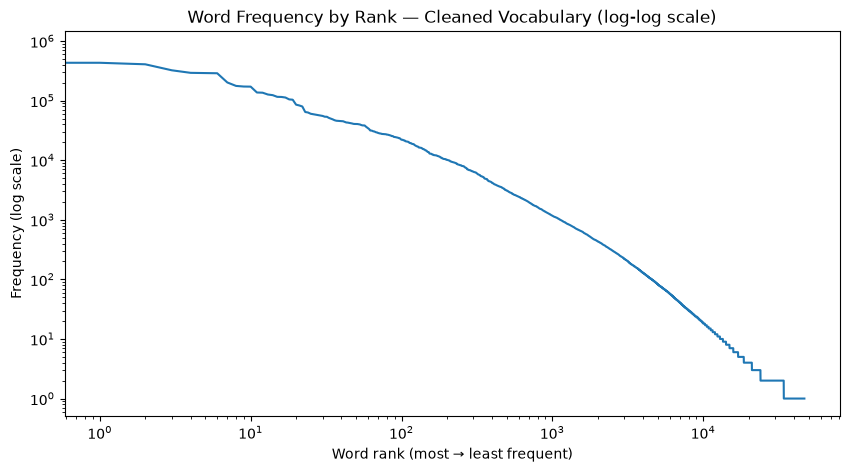

In [34]:
# --- Zipf's Law plot, using cleaned counts ---
sorted_freqs = sorted(word_counts_clean.values(), reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(sorted_freqs)
plt.yscale('log')
plt.xscale('log')
plt.title("Word Frequency by Rank — Cleaned Vocabulary (log-log scale)")
plt.xlabel('Word rank (most → least frequent)')
plt.ylabel('Frequency (log scale)')
plt.show()


Our initial word count used naive whitespace splitting, which inflated the vocabulary with punctuation-glued duplicates (e.g., `"good."` and `"good"` counted as different words) — 74.5% of the raw "vocabulary" contained non-alphabetic characters. After tokenizing properly with a regex that strips punctuation while preserving contractions (`i'm`, `don't`), the true vocabulary drops from 154,505 to **46,898 unique words** — a 69.6% reduction. Of these, 18,581 words (~39.6%) appear 5+ times.

**Decision:** cap the embedding vocabulary using `min_frequency=5`, giving a final vocabulary size of approximately **18,581 words** — a substantially smaller and more accurate embedding layer than our initial estimate.

In [36]:
print("Unique drugs:", train_df['drugName'].nunique())
print("Unique conditions:", train_df['condition'].nunique())

Unique drugs: 3436
Unique conditions: 812


In [37]:
train_df['drugName'].value_counts().tail(20)

drugName
Pacerone                           1
Valganciclovir                     1
Urised                             1
Folotyn                            1
Amevive                            1
Mylanta Gas                        1
Midol Extended Relief              1
Desloratadine / pseudoephedrine    1
Extina                             1
Lomaira                            1
Acarbose                           1
Antihemophilic factor              1
Zileuton                           1
Amethyst                           1
Midamor                            1
Oxytocin                           1
Iluvien                            1
Mavik                              1
Aldomet                            1
Grifulvin V                        1
Name: count, dtype: int64

In [39]:
print(train_df['drugName'].value_counts().head(10))
print(train_df['condition'].value_counts().head(10))

drugName
Levonorgestrel                        3657
Etonogestrel                          3336
Ethinyl estradiol / norethindrone     2850
Nexplanon                             2156
Ethinyl estradiol / norgestimate      2117
Ethinyl estradiol / levonorgestrel    1888
Phentermine                           1543
Sertraline                            1360
Escitalopram                          1292
Mirena                                1242
Name: count, dtype: int64
condition
Birth Control      28788
Depression          9069
Pain                6145
Anxiety             5904
Acne                5588
Bipolar Disorde     4224
Insomnia            3673
Weight Loss         3609
Obesity             3568
ADHD                3383
Name: count, dtype: int64


In [ ]:
unique_conditions = train_df['condition'].dropna().unique()
lowercase_start = sorted([c for c in unique_conditions if c[0].islower()])
print(f"Conditions starting with lowercase: {len(lowercase_start)}")
print(lowercase_start)

truncated_suffixes = ['Disorde', 'Cance', 'Ulce', 'Feve', 'Tum', 'Zoste', 'Trem', 'Bladde', 'Shoulde', 'Flutte', 'Behavi']

affected = train_df[train_df['condition'].str.endswith(tuple(truncated_suffixes), na=False) | 
                     train_df['condition'].apply(lambda c: isinstance(c, str) and c[0].islower())]
print()
print(f"Rows with a likely truncated condition value: {len(affected)} ({len(affected)/len(train_df)*100:.1f}% of dataset)")

print()
print("Number of reviews for 'Bipolar Disorde' versus 'Bipolar Disorder':")
print(f"'Bipolar Disorde': {train_df[train_df['condition'] == 'Bipolar Disorde'].shape[0]}")
print(f"'Bipolar Disorder': {train_df[train_df['condition'] == 'Bipolar Disorder'].shape[0]}")

Conditions starting with lowercase: 37
['acial Lipoatrophy', 'acial Wrinkles', 'actor IX Deficiency', 'ailure to Thrive', 'amilial Cold Autoinflammatory Syndrome', 'amilial Mediterranean Feve', 'atigue', 'cal Segmental Glomerulosclerosis', 'emale Infertility', 'eve', 'ge (amlodipine / valsartan)', 'ge HCT (amlodipine / hydrochlorothiazide / valsartan)', 'ibrocystic Breast Disease', 'ibromyalgia', 'lic Acid Deficiency', 'llicular Lymphoma', 'm Pain Disorde', 'mance Anxiety', 'me', 'min / pioglitazone)', 'min / rosiglitazone)', 'min / saxagliptin)', 'min / sitagliptin)', 'min)', 'mis', 'mist (', 'moterol / mometasone)', 'moterol)', 'mulation) (phenylephrine)', 't Care', 't Pac with Cyclobenzaprine (cyclobenzaprine)', 'tic (mycophenolic acid)', 'unctional Gastric Disorde', 'ungal Infection Prophylaxis', 'ungal Pneumonia', "von Willebrand's Disease", 'zen Shoulde']

Rows with a likely truncated condition value: 14947 (9.3% of dataset)

Number of reviews for 'Bipolar Disorde' versus 'Bipola

We checked both fields for anomalies: 3,436 unique drugs and 812 unique conditions. `drugName`'s tail values (rarest entries) all turned out to be legitimate drug names — no issues there. `condition`'s top-10 most frequent values, however, revealed a problem: `"Bipolar Disorde"` appears 4,224 times — a truncated version of "Bipolar Disorder," missing its final letter. This wasn't a rare edge case; it was sitting among the most common conditions in the dataset.

Filtering for conditions starting with a lowercase letter surfaced a second, related pattern — values like `"ibrocystic Breast Disease"` and `"ungal Pneumonia"` are missing their leading letter (typically "F"), confirming this is a broader truncation issue affecting both the start and end of condition strings, not an isolated typo. Checking whether the error is at least consistent — confirming every instance of `"Bipolar Disorde"` is missing the same trailing "r," with zero properly-spelled `"Bipolar Disorder"` rows existing instead — showed the corruption is systematic rather than random per row.

In total, **9.3% of the dataset (14,947 rows)** have a likely truncated `condition` value. This same truncation is visible in other public copies of this dataset on Kaggle, confirming it originates from the original source data rather than anything introduced in our pipeline.
we document it here as a known data limitation rather than correcting it.

### EDA Summary

This notebook explored the cleaned training set to inform model configuration.
Key findings:
* the rating distribution is heavily imbalanced (U-shaped, skewed toward extremes), requiring class weighting and macro-F1 as an evaluation metric rather than relying on accuracy alone.
* Review length is tightly clustered with a long tail of rare outliers, supporting a `max_sequence_length` of 160 tokens — applied at tokenization time.
* Proper tokenization (stripping punctuation, preserving contractions) reduced the true vocabulary from 154,505 to 46,898 words, with ~18,581 words appearing 5+ times — the basis for our embedding vocabulary size.